# 02 Preprocessing

Notebook de validation visuelle du preprocessing et du pipeline d'augmentation de l'étape 4.5.

Objectifs :
- visualiser les transformations sur des images réelles,
- vérifier que `train_transform` reste plausible visuellement,
- comparer PlantVillage et PlantDoc après normalisation,
- vérifier que `val_transform` ne fait que resize + normalize.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

REPO_ROOT = Path.cwd().resolve()
if not (REPO_ROOT / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.augmentation import (
    IMAGE_SIZE,
    IMAGENET_MEAN,
    IMAGENET_STD,
    train_transform,
    val_transform,
)

plt.style.use("ggplot")

PLANTVILLAGE_SAMPLE_DIR = REPO_ROOT / "data" / "processed" / "tomato" / "train" / "Early_Blight"
PLANTDOC_SAMPLE_DIR = REPO_ROOT / "data" / "test_ood" / "tomato" / "Early_Blight"


def load_image(image_path: Path) -> np.ndarray:
    return np.array(Image.open(image_path).convert("RGB"))


def denormalize(image: np.ndarray) -> np.ndarray:
    image = image.copy()
    image = image * np.array(IMAGENET_STD, dtype=np.float32) + np.array(IMAGENET_MEAN, dtype=np.float32)
    image = np.clip(image, 0, 1)
    return image


def show_grid(images, titles, ncols=3, figsize=(14, 8)):
    n_images = len(images)
    nrows = int(np.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)

    for ax, image, title in zip(axes, images, titles):
        ax.imshow(image)
        ax.set_title(title, fontsize=10)
        ax.axis("off")

    for ax in axes[n_images:]:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


plantvillage_image_path = sorted(PLANTVILLAGE_SAMPLE_DIR.glob("*"))[0]
plantdoc_image_path = sorted(PLANTDOC_SAMPLE_DIR.glob("*"))[0]

plantvillage_image = load_image(plantvillage_image_path)
plantdoc_image = load_image(plantdoc_image_path)

print("PlantVillage sample:", plantvillage_image_path.name, plantvillage_image.shape, plantvillage_image.dtype)
print("PlantDoc sample:", plantdoc_image_path.name, plantdoc_image.shape, plantdoc_image.dtype)


PlantVillage sample: 0034a551-9512-44e5-ba6c-827f85ecc688___RS_Erly.B 9432.JPG (256, 256, 3) uint8
PlantDoc sample: Tomato_Early_blight_leaf__test_Tomato Early blight leaf_1.jpg (378, 257, 3) uint8


/home/thomashebert99/.pyenv/versions/plant-disease-detection/lib/python3.11/site-packages/albumentations/__init__.py:24: UserWarning: A new version of Albumentations is available: 2.0.8 (you have 1.4.24). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


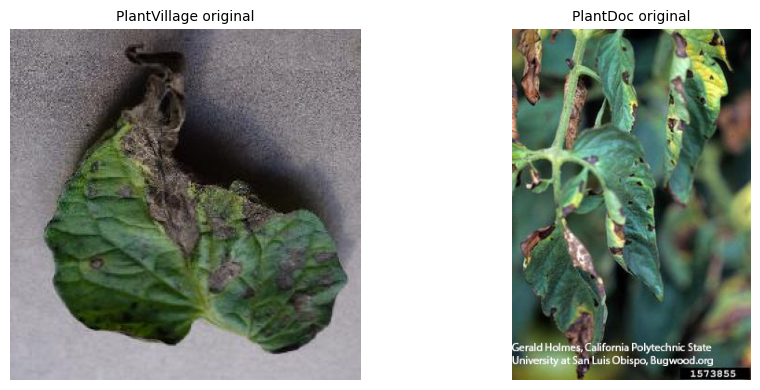

In [2]:
show_grid(
    [plantvillage_image, plantdoc_image],
    ["PlantVillage original", "PlantDoc original"],
    ncols=2,
    figsize=(10, 4),
)


## Validation visuelle de `train_transform`

Le but ici est de vérifier que l'augmentation reste crédible visuellement et simule bien des conditions terrain sans détruire l'information maladie.


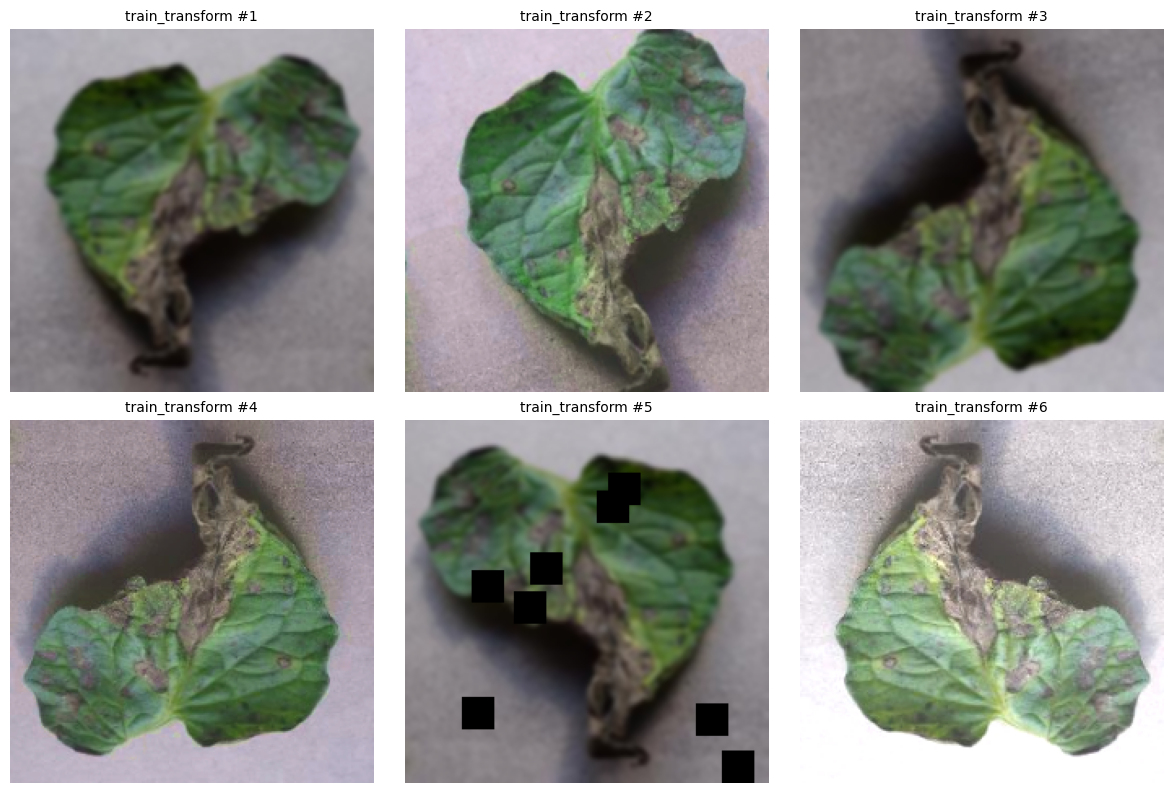

In [3]:
augmented_images = []
titles = []
for index in range(6):
    augmented = train_transform(image=plantvillage_image)["image"]
    augmented_images.append(denormalize(augmented))
    titles.append(f"train_transform #{index + 1}")

show_grid(augmented_images, titles, ncols=3, figsize=(12, 8))


In [4]:
train_result = train_transform(image=plantvillage_image)["image"]
print("train_transform shape:", train_result.shape)
print("train_transform dtype:", train_result.dtype)
print("train_transform min/max:", float(train_result.min()), float(train_result.max()))


train_transform shape: (224, 224, 3)
train_transform dtype: float32
train_transform min/max: -2.0665297508239746 1.646535873413086


## Vérification de `val_transform`

`val_transform` ne doit faire aucune augmentation aléatoire : seulement resize + normalize.


In [5]:
print([type(transform).__name__ for transform in val_transform.transforms])

val_result = val_transform(image=plantvillage_image)["image"]
print("val_transform shape:", val_result.shape)
print("val_transform dtype:", val_result.dtype)
print("val_transform min/max:", float(val_result.min()), float(val_result.max()))


['Resize', 'Normalize']
val_transform shape: (224, 224, 3)
val_transform dtype: float32
val_transform min/max: -2.0665297508239746 1.646535873413086


## Comparaison PlantVillage vs PlantDoc après normalisation

On compare ici les deux datasets après passage dans `val_transform` pour vérifier que le preprocessing est cohérent malgré le domain gap visuel initial.


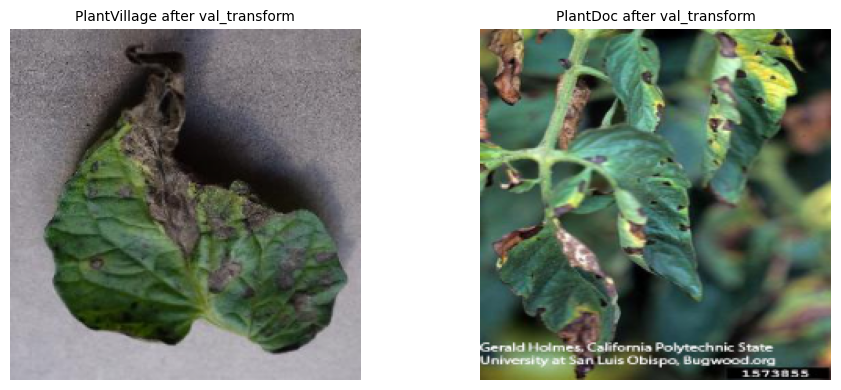

In [6]:
plantvillage_val = val_transform(image=plantvillage_image)["image"]
plantdoc_val = val_transform(image=plantdoc_image)["image"]

show_grid(
    [denormalize(plantvillage_val), denormalize(plantdoc_val)],
    ["PlantVillage after val_transform", "PlantDoc after val_transform"],
    ncols=2,
    figsize=(10, 4),
)


## Conclusion

- `train_transform` ajoute des perturbations réalistes pour simuler des conditions terrain.
- `val_transform` reste strictement déterministe : resize + normalize uniquement.
- Les dimensions de sortie sont bien de `224 x 224`.
- Les valeurs de pixels normalisées restent dans une plage compatible ImageNet.
- Une fois cette validation visuelle jugée satisfaisante, le pipeline est figé dans `src/data/augmentation.py`.
